# 🚀 Gradient Boosting & XGBoost - Complete Learning Guide

## Overview
Gradient Boosting is an ensemble technique that builds models sequentially, with each new model correcting errors made by previous models. XGBoost (eXtreme Gradient Boosting) is an optimized implementation with regularization and parallel processing.

## Key Topics Covered:
1. **Boosting Fundamentals** - Sequential model building
2. **Gradient Boosting Theory** - Loss functions and gradients
3. **XGBoost Advantages** - Regularization and efficiency
4. **Classification & Regression** - Both applications
5. **Hyperparameter Tuning** - Learning rate, max_depth, etc.
6. **Feature Importance** - Understanding model decisions
7. **Early Stopping** - Preventing overfitting
8. **Real-world Applications** - Practical examples

---

## References:
- [XGBoost Documentation](https://xgboost.readthedocs.io/)
- [Gradient Boosting Paper](https://en.wikipedia.org/wiki/Gradient_boosting)
- [XGBoost: A Scalable Tree Boosting System](https://arxiv.org/abs/1603.02754)

## 📚 Section 1: Import Libraries

In [11]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, AdaBoostClassifier
from sklearn.datasets import load_iris, load_breast_cancer, make_regression, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report,
    mean_squared_error, r2_score, mean_absolute_error
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🚀 Section 2: Gradient Boosting Classification


🚀 EXAMPLE 1: Gradient Boosting Classification

✅ Gradient Boosting Classification Performance:
  Accuracy:  0.9649
  Precision: 0.9589
  Recall:    0.9859
  F1 Score:  0.9722
  ROC-AUC:   0.9902

✅ Gradient Boosting Classification Performance:
  Accuracy:  0.9649
  Precision: 0.9589
  Recall:    0.9859
  F1 Score:  0.9722
  ROC-AUC:   0.9902


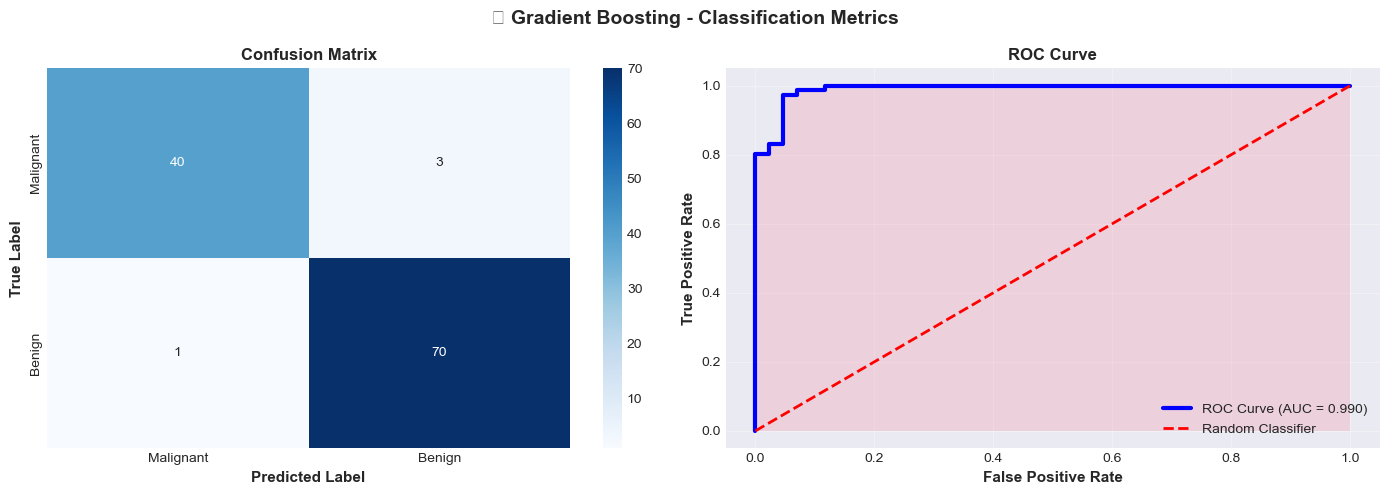

In [12]:
# Example 1: Gradient Boosting Classification
print("\n" + "="*70)
print("🚀 EXAMPLE 1: Gradient Boosting Classification")
print("="*70)

# Load dataset
cancer_data = load_breast_cancer()
X_cancer = cancer_data.data
y_cancer = cancer_data.target

# Split data
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cancer)
X_test_scaled = scaler.transform(X_test_cancer)

# Train Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, 
                                     max_depth=5, random_state=42)
gb_clf.fit(X_train_scaled, y_train_cancer)

# Predictions
y_pred = gb_clf.predict(X_test_scaled)
y_pred_proba = gb_clf.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test_cancer, y_pred)
precision = precision_score(y_test_cancer, y_pred)
recall = recall_score(y_test_cancer, y_pred)
f1 = f1_score(y_test_cancer, y_pred)
roc_auc = roc_auc_score(y_test_cancer, y_pred_proba)

print(f"\n✅ Gradient Boosting Classification Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🚀 Gradient Boosting - Classification Metrics', fontsize=14, fontweight='bold')

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test_cancer, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test_cancer, y_pred_proba)
ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📈 Section 3: Gradient Boosting Regression


📈 EXAMPLE 2: Gradient Boosting Regression

✅ Gradient Boosting Regression Performance:
  R² Score: 0.7267
  MSE:      8699.4396
  RMSE:     93.2708
  MAE:      72.4522


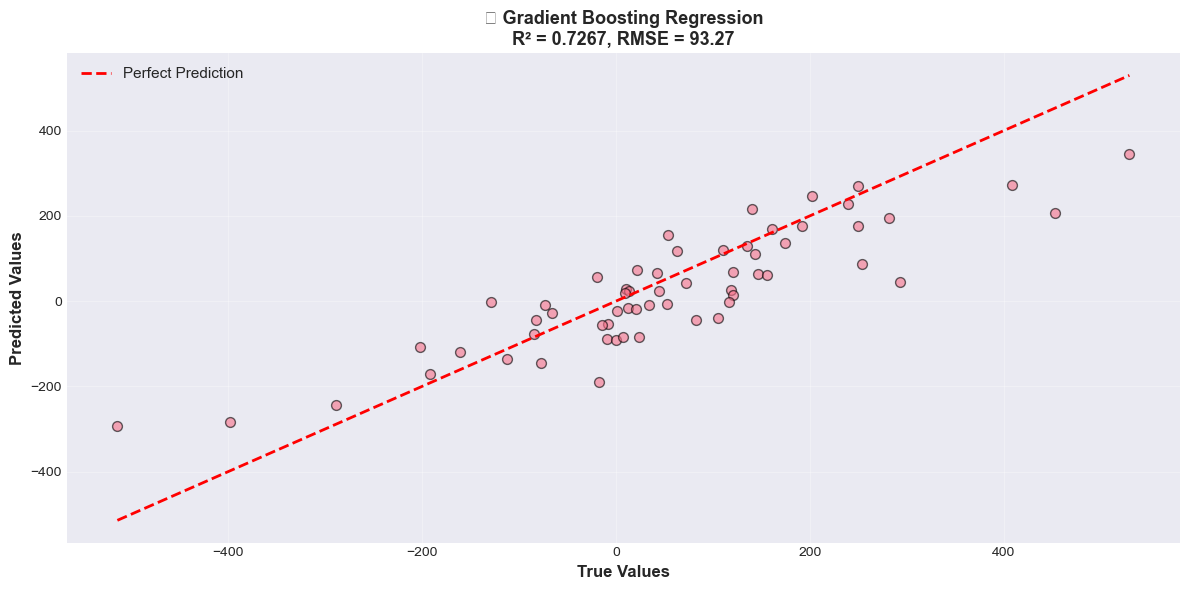

In [13]:
# Example 2: Gradient Boosting Regression
print("\n" + "="*70)
print("📈 EXAMPLE 2: Gradient Boosting Regression")
print("="*70)

# Create regression data
X_reg, y_reg = make_regression(n_samples=300, n_features=10, noise=20, random_state=42)

# Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Train Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                    max_depth=5, random_state=42)
gb_reg.fit(X_train_reg_scaled, y_train_reg)

# Predictions
y_pred_reg = gb_reg.predict(X_test_reg_scaled)

# Metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"\n✅ Gradient Boosting Regression Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  MSE:      {mse:.4f}")
print(f"  RMSE:     {rmse:.4f}")
print(f"  MAE:      {mae:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Actual vs Predicted
ax.scatter(y_test_reg, y_pred_reg, alpha=0.6, s=50, edgecolors='k')
# Perfect prediction line
lims = [np.min([y_test_reg.min(), y_pred_reg.min()]),
        np.max([y_test_reg.max(), y_pred_reg.max()])]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')

ax.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
ax.set_title(f'📈 Gradient Boosting Regression\nR² = {r2:.4f}, RMSE = {rmse:.2f}',
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Section 4: Feature Importance in Boosting


📊 EXAMPLE 3: Feature Importance in Gradient Boosting

🎯 Top 10 Most Important Features:
   1. mean concave points       = 0.6862
   2. worst concave points      = 0.0700
   3. worst radius              = 0.0536
   4. worst perimeter           = 0.0515
   5. worst texture             = 0.0367
   6. mean texture              = 0.0312
   7. concave points error      = 0.0158
   8. concavity error           = 0.0111
   9. worst smoothness          = 0.0094
  10. fractal dimension error   = 0.0079


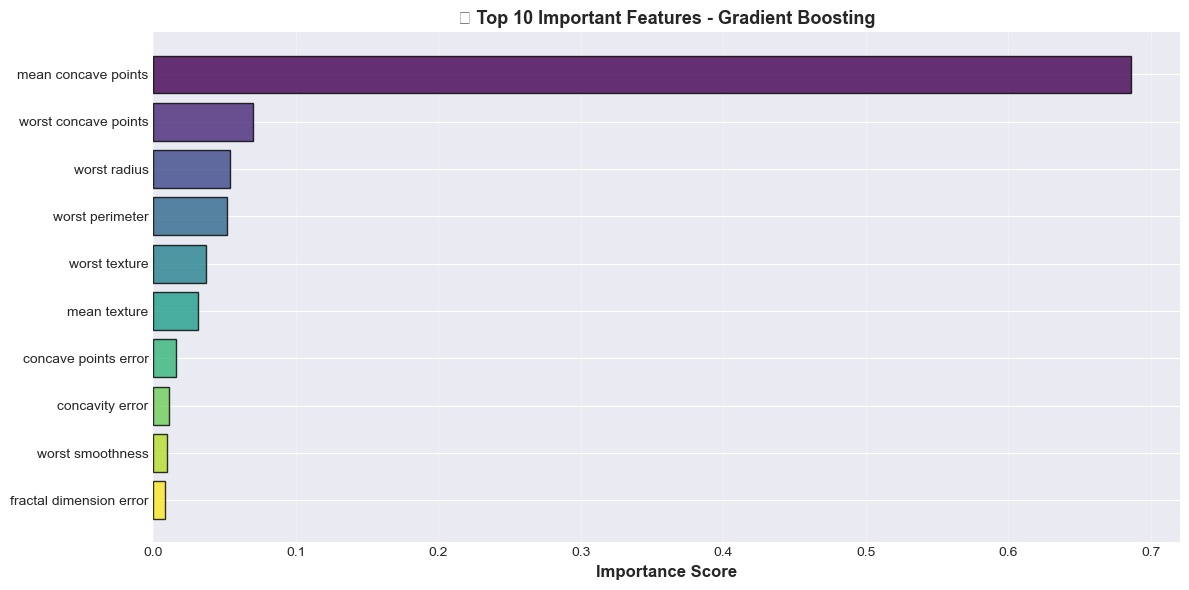

In [14]:
# Example 3: Feature Importance
print("\n" + "="*70)
print("📊 EXAMPLE 3: Feature Importance in Gradient Boosting")
print("="*70)

# Get feature importances
feature_importance = gb_clf.feature_importances_
feature_names = cancer_data.feature_names

# Sort by importance
indices = np.argsort(feature_importance)[::-1]

print(f"\n🎯 Top 10 Most Important Features:")
for i, idx in enumerate(indices[:10], 1):
    print(f"  {i:2d}. {feature_names[idx]:25s} = {feature_importance[idx]:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

top_10_idx = indices[:10]
top_10_names = [feature_names[i] for i in top_10_idx]
top_10_importance = feature_importance[top_10_idx]

colors_bar = plt.cm.viridis(np.linspace(0, 1, 10))
ax.barh(range(10), top_10_importance, color=colors_bar, edgecolor='black', alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_names, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('📊 Top 10 Important Features - Gradient Boosting', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## ⚙️ Section 5: Learning Rate & Early Stopping


⚙️ EXAMPLE 4: Learning Rate Impact

📊 Testing different learning rates:
  LR: 0.001 -> Train: 0.6286, Test: 0.6228
  LR: 0.001 -> Train: 0.6286, Test: 0.6228
  LR: 0.010 -> Train: 0.9956, Test: 0.9386
  LR: 0.010 -> Train: 0.9956, Test: 0.9386
  LR: 0.050 -> Train: 1.0000, Test: 0.9561
  LR: 0.050 -> Train: 1.0000, Test: 0.9561
  LR: 0.100 -> Train: 1.0000, Test: 0.9649
  LR: 0.100 -> Train: 1.0000, Test: 0.9649
  LR: 0.200 -> Train: 1.0000, Test: 0.9649
  LR: 0.200 -> Train: 1.0000, Test: 0.9649
  LR: 0.300 -> Train: 1.0000, Test: 0.9561
  LR: 0.300 -> Train: 1.0000, Test: 0.9561


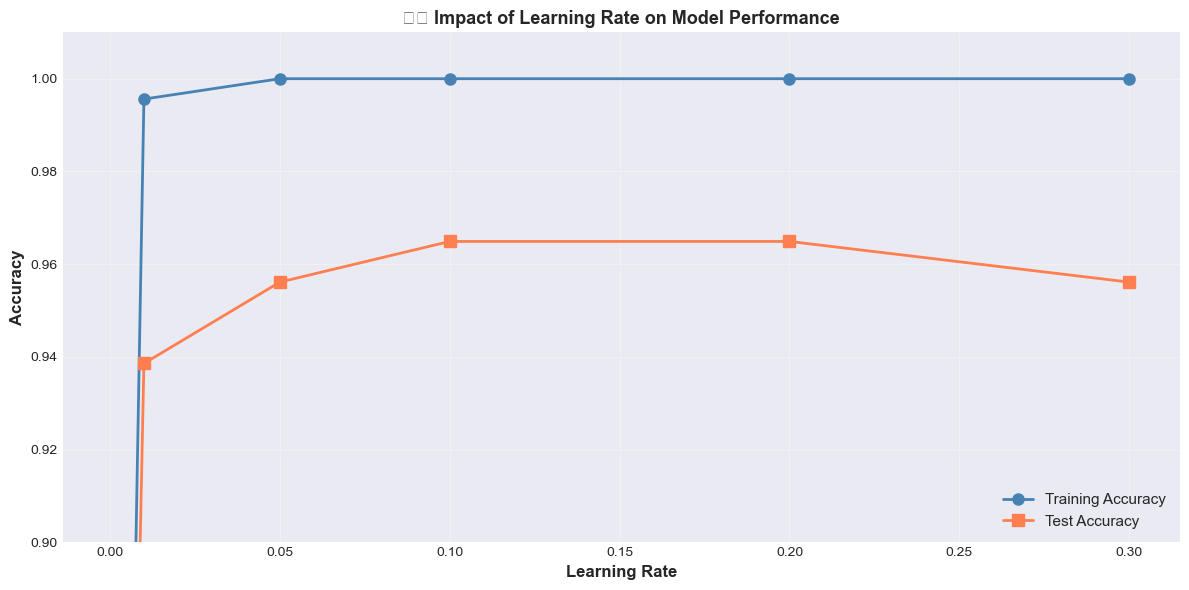

In [15]:
# Example 4: Impact of Learning Rate
print("\n" + "="*70)
print("⚙️ EXAMPLE 4: Learning Rate Impact")
print("="*70)

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
train_scores = []
test_scores = []

print(f"\n📊 Testing different learning rates:")
for lr in learning_rates:
    gb_temp = GradientBoostingClassifier(n_estimators=100, learning_rate=lr,
                                         max_depth=5, random_state=42)
    gb_temp.fit(X_train_scaled, y_train_cancer)
    
    train_acc = accuracy_score(y_train_cancer, gb_temp.predict(X_train_scaled))
    test_acc = accuracy_score(y_test_cancer, gb_temp.predict(X_test_scaled))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    print(f"  LR: {lr:.3f} -> Train: {train_acc:.4f}, Test: {test_acc:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(learning_rates, train_scores, 'o-', linewidth=2, markersize=8,
        label='Training Accuracy', color='steelblue')
ax.plot(learning_rates, test_scores, 's-', linewidth=2, markersize=8,
        label='Test Accuracy', color='coral')

ax.set_xlabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('⚙️ Impact of Learning Rate on Model Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.9, 1.01])

plt.tight_layout()
plt.show()

## 🎯 Section 6: Boosting vs Bagging vs Single Tree


🎯 EXAMPLE 5: Gradient Boosting vs Other Algorithms

🧪 Training and evaluating algorithms...

✅ Performance Comparison:
                   Accuracy  Precision    Recall        F1
Decision Tree      0.947368   0.957746  0.957746  0.957746
Random Forest      0.964912   0.958904  0.985915  0.972222
AdaBoost           0.973684   0.972222  0.985915  0.979021
Gradient Boosting  0.964912   0.958904  0.985915  0.972222

✅ Performance Comparison:
                   Accuracy  Precision    Recall        F1
Decision Tree      0.947368   0.957746  0.957746  0.957746
Random Forest      0.964912   0.958904  0.985915  0.972222
AdaBoost           0.973684   0.972222  0.985915  0.979021
Gradient Boosting  0.964912   0.958904  0.985915  0.972222


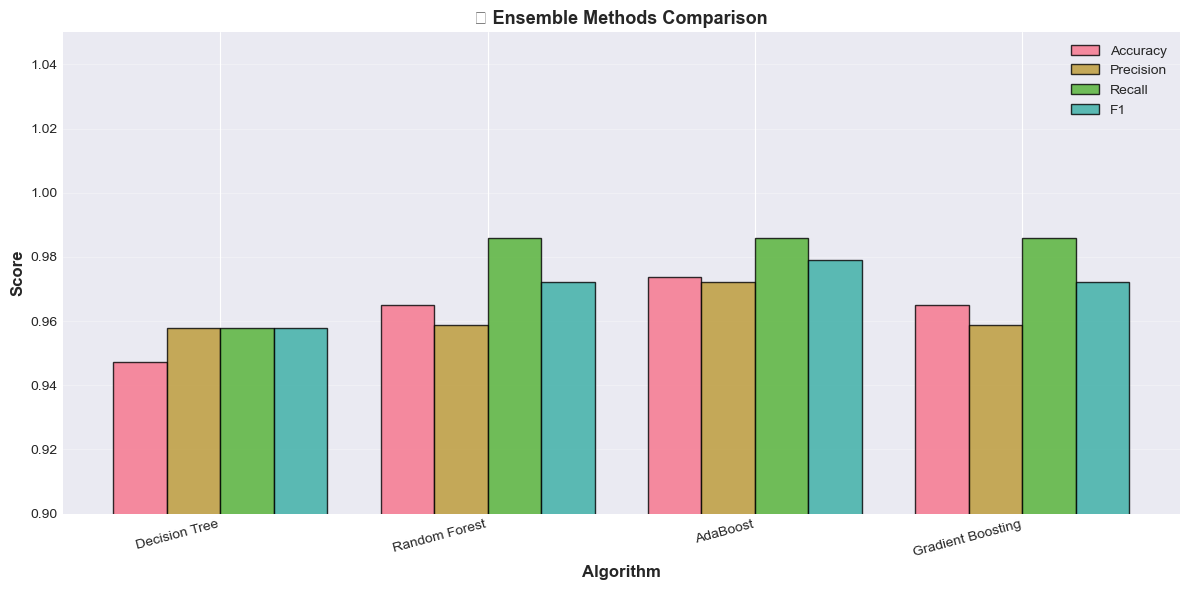

In [16]:
# Example 5: Algorithm Comparison
print("\n" + "="*70)
print("🎯 EXAMPLE 5: Gradient Boosting vs Other Algorithms")
print("="*70)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

algorithms = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

results = {}
print(f"\n🧪 Training and evaluating algorithms...")

for name, model in algorithms.items():
    model.fit(X_train_scaled, y_train_cancer)
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test_cancer, y_pred)
    precision = precision_score(y_test_cancer, y_pred)
    recall = recall_score(y_test_cancer, y_pred)
    f1 = f1_score(y_test_cancer, y_pred)
    
    results[name] = {'Accuracy': accuracy, 'Precision': precision,
                     'Recall': recall, 'F1': f1}

# Create results dataframe
results_df = pd.DataFrame(results).T
print(f"\n✅ Performance Comparison:")
print(results_df.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df.index))
width = 0.2
metrics = results_df.columns

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric, alpha=0.8, edgecolor='black')

ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('🎯 Ensemble Methods Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.9, 1.05])

plt.tight_layout()
plt.show()

## 📋 Section 7: Gradient Boosting Advantages & Disadvantages

### ✅ Advantages:
1. **High accuracy** - Often best performing algorithm
2. **Sequential improvement** - Each tree corrects previous errors
3. **Feature importance** - Good interpretability
4. **Handles non-linearity** - Flexible decision boundaries
5. **Works well with mixed data** - Handles various feature types
6. **Reduces overfitting** - Regularization options available

### ❌ Disadvantages:
1. **Slow training** - Sequential building (can't parallelize)
2. **Slow predictions** - Must evaluate all trees
3. **Hyperparameter sensitive** - Many parameters to tune
4. **Memory intensive** - Stores many trees
5. **Risk of overfitting** - Can memorize training data if not careful
6. **Hard to interpret** - Black box compared to single tree

### When to Use:
- When you need maximum accuracy
- Kaggle competitions
- Production systems where accuracy matters most
- Binary classification problems
- When you have time for hyperparameter tuning

In [17]:
# Example 6: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "Gradient Boosting builds trees sequentially to correct errors",
    "Each tree uses residuals (errors) from previous trees",
    "Learning rate controls how much each tree contributes",
    "Lower learning rate = slower training but often better accuracy",
    "n_estimators = number of boosting stages",
    "max_depth typically shallow (5-10) for boosting",
    "Feature importance shows which features matter most",
    "Gradient Boosting usually outperforms Random Forest",
    "XGBoost is faster and better for large datasets",
    "Always validate with cross-validation before deployment"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. Gradient Boosting builds trees sequentially to correct errors

 2. Each tree uses residuals (errors) from previous trees

 3. Learning rate controls how much each tree contributes

 4. Lower learning rate = slower training but often better accuracy

 5. n_estimators = number of boosting stages

 6. max_depth typically shallow (5-10) for boosting

 7. Feature importance shows which features matter most

 8. Gradient Boosting usually outperforms Random Forest

 9. XGBoost is faster and better for large datasets

10. Always validate with cross-validation before deployment

